<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 40%, #0f3460 100%); padding: 40px 30px; border-radius: 16px; text-align: center; font-family: 'Georgia', serif; margin-bottom: 10px;">
  <div style="font-size: 13px; letter-spacing: 4px; color: #e2b96f; text-transform: uppercase; margin-bottom: 8px;">University Course Material</div>
  <div style="font-size: 28px; font-weight: bold; color: #ffffff; letter-spacing: 1px; margin-bottom: 4px;">MATH 4650: Probabilistic Deep Learning</div>
  <div style="width: 80px; height: 3px; background: #e2b96f; margin: 14px auto;"></div>
  <div style="font-size: 22px; color: #e2b96f; font-weight: bold; margin-bottom: 8px;">In-Class Activity: Extending a CNN Architecture</div>
  <div style="font-size: 15px; color: #a8c6e8; margin-bottom: 4px;">Modifying a 3-Block CNN → 4-Block CNN on MNIST</div>
  <div style="width: 50px; height: 1px; background: #a8c6e8; margin: 14px auto;"></div>
  <div style="font-size: 13px; color: #c8d8ea; margin-top: 6px;">Spring 2026 &nbsp;|&nbsp; Instructor: <strong style='color:#e2b96f;'>Dr. Jishan Ahmed</strong></div>
</div>

---

## 📋 Instructions

> **Before you begin:** Upload `shared_utilities.py` to your Colab session using the file browser on the left sidebar (📁 icon → Upload). This file provides the `LightningModel`, `MnistDataModule`, and `plot_loss_and_acc` helpers used in today's tutorial.

**What you will do today:**

You have the 3-block `PyTorchCNN` from the tutorial. Your task is to **extend it to a 4-block CNN** by making two targeted changes to the architecture and one change to the training configuration — no new helper code needed.

Work through the cells in order. Cells marked 🔧 **YOUR TASK** require you to fill in or modify code.

---

## Step 1 — Verify Your GPU

Make sure you have selected **Runtime → Change runtime type → T4 GPU** and **High-RAM** in Google Colab before running anything.

Run the cell below to confirm your hardware.

In [ ]:
# ── GPU & RAM Verification ─────────────────────────────────────────────────
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
    print('Not connected to a GPU')
else:
    print(gpu_info)

import psutil
ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
    print('Not using a high-RAM runtime')
else:
    print('You are using a high-RAM runtime!')

Thu Apr 16 15:43:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

---
## Step 2 — Install Dependencies & Import Libraries

In [ ]:
# Install required packages (Colab may not have lightning pre-installed)
!pip install lightning torchmetrics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 50.1 MB/s eta 0:00:00


In [ ]:
import lightning as L
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from lightning.pytorch.loggers import CSVLogger

# From your uploaded shared_utilities.py
from shared_utilities import LightningModel, MnistDataModule, plot_loss_and_acc

print("All imports successful!")
print(f"PyTorch version : {torch.__version__}")
print(f"Lightning version: {L.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

All imports successful!
PyTorch version : 2.10.0+cu128
Lightning version: 2.6.1
CUDA available  : True


---
## Step 3 — Review: The Original 3-Block CNN

Below is the original `PyTorchCNN` from the tutorial. **Read it carefully** and trace the shape of the data through each block before attempting the task.

### Shape Trace — Fill In the Table

Complete the table by computing the output shape after each operation. Use the formula:

$$\text{Output size} = \left\lfloor \frac{\text{Input size} - \text{kernel size}}{\text{stride}} \right\rfloor + 1$$

For `MaxPool2d(kernel_size=2)`, output size = input size ÷ 2.

| Layer | Operation | Output Shape (C, H, W) |
|---|---|---|
| Input | — | (1, 28, 28) |
| Block 1 | Conv2d(1→3, k=5) | (3, **?**, **?**) |
| Block 1 | MaxPool2d(2) | (3, **?**, **?**) |
| Block 2 | Conv2d(3→16, k=3) | (16, **?**, **?**) |
| Block 2 | MaxPool2d(2) | (16, **?**, **?**) |
| Block 3 | Conv2d(16→32, k=3) | (32, **?**, **?**) |
| Block 3 | MaxPool2d(2) | (32, **?**, **?**) |
| Flatten | — | (**?**,) |

> 💡 **Hint:** The final flattened size tells you what number to use in `Linear(?, 20)` inside `fc_layers`.

In [ ]:
# ── Original 3-Block CNN (from Tutorial) — DO NOT MODIFY THIS CELL ─────────

class PyTorchCNN(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn_layers = torch.nn.Sequential(

            # Block 1 — Input: (1, 28, 28) → Output: (3, 12, 12)
            torch.nn.Conv2d(1, 3, kernel_size=5),
            torch.nn.BatchNorm2d(3),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),

            # Block 2 — Input: (3, 12, 12) → Output: (16, 5, 5)
            torch.nn.Conv2d(3, 16, kernel_size=3),
            torch.nn.BatchNorm2d(16),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),

            # Block 3 — Input: (16, 5, 5) → Output: (32, 1, 1)
            torch.nn.Conv2d(16, 32, kernel_size=3),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),
        )

        self.fc_layers = torch.nn.Sequential(
            torch.nn.Linear(32, 20),
            torch.nn.BatchNorm1d(20),
            torch.nn.ReLU(),
            torch.nn.Linear(20, num_classes),
        )

    def forward(self, x):
        x = self.cnn_layers(x)
        x = torch.flatten(x, start_dim=1)
        logits = self.fc_layers(x)
        return logits

print("Original 3-block CNN defined.")

Original 3-block CNN defined.


In [ ]:
!pip install torchinfo

In [ ]:
# install once
# pip install torchinfo

import torch
from torchinfo import summary

model = PyTorchCNN(num_classes=10)

summary(
    model,
    input_size=(1, 1, 28, 28),   # (batch_size, channels, height, width)
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
PyTorchCNN                               [1, 1, 28, 28]            [1, 10]                   --                        True
├─Sequential: 1-1                        [1, 1, 28, 28]            [1, 32, 1, 1]             --                        True
│    └─Conv2d: 2-1                       [1, 1, 28, 28]            [1, 3, 24, 24]            78                        True
│    └─BatchNorm2d: 2-2                  [1, 3, 24, 24]            [1, 3, 24, 24]            6                         True
│    └─ReLU: 2-3                         [1, 3, 24, 24]            [1, 3, 24, 24]            --                        --
│    └─MaxPool2d: 2-4                    [1, 3, 24, 24]            [1, 3, 12, 12]            --                        --
│    └─Conv2d: 2-5                       [1, 3, 12, 12]            [1, 16, 10, 10]           448                       True
│    └─

---
## Step 4 — 🔧 YOUR TASK: Build a 4-Block CNN

### Background

Look at the shape trace table above. After Block 3's `MaxPool2d`, the spatial dimensions collapse to **1×1** — there is no room to add another convolution + pooling on top.

To make space for a 4th convolutional block we need to **remove the `MaxPool2d` from Block 3**. This keeps the feature map at **3×3** after Block 3's convolution, which is just enough for one more `Conv2d(kernel_size=3)` in Block 4.

### What You Need to Change

**Change 1 — `cnn_layers`:** In Block 3, remove `torch.nn.MaxPool2d(kernel_size=2)` and add a new Block 4:

```
# Block 4 — Input: (32, 3, 3) → Output: (64, 1, 1)
Conv2d(32 → 64, kernel_size=3)
BatchNorm2d(64)
ReLU()
```
> Note: No `MaxPool2d` in Block 4 — after Conv2d(k=3) on a 3×3 map the spatial size is already 1×1.

**Change 2 — `fc_layers`:** The flattened feature vector is now size **64** (not 32). Update `Linear(32, 20)` → `Linear(64, 20)`.

Everything else — `forward()`, the training setup, `LightningModel`, `MnistDataModule` — stays exactly the same.

### Shape Trace for the 4-Block CNN

| Layer | Operation | Output Shape (C, H, W) |
|---|---|---|
| Input | — | (1, 28, 28) |
| Block 1 | Conv2d(1→3, k=5) + MaxPool | (3, 12, 12) |
| Block 2 | Conv2d(3→16, k=3) + MaxPool | (16, 5, 5) |
| Block 3 | Conv2d(16→32, k=3) — **no MaxPool** | (32, 3, 3) |
| Block 4 | Conv2d(32→64, k=3) | (64, 1, 1) |
| Flatten | — | (64,) |
| fc_layers | Linear(**64**→20) → BN → ReLU → Linear(20→10) | 10 logits |

In [ ]:
# ── 🔧 YOUR TASK: Complete the 4-Block CNN below ───────────────────────────
# Follow the two changes described above.
# Only edit the lines marked with  <-- CHANGE THIS

class PyTorchCNN4Block(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn_layers = torch.nn.Sequential(

            # Block 1 — unchanged
            torch.nn.Conv2d(1, 3, kernel_size=5),
            torch.nn.BatchNorm2d(3),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),

            # Block 2 — unchanged
            torch.nn.Conv2d(3, 16, kernel_size=3),
            torch.nn.BatchNorm2d(16),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2),

            # Block 3 — remove MaxPool2d here
            torch.nn.Conv2d(16, 32, kernel_size=3),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
              # <-- CHANGE THIS (delete this line)

           # Block 4 — Input: (32, 3, 3) → Output: (64, 1, 1)
            torch.nn.Conv2d(32,64, kernel_size=3),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU()
        )

        self.fc_layers = torch.nn.Sequential(
            torch.nn.Linear(64, 20),   # <-- CHANGE THIS (update input size)
            torch.nn.BatchNorm1d(20),
            torch.nn.ReLU(),
            torch.nn.Linear(20, num_classes),
        )

    def forward(self, x):
        x = self.cnn_layers(x)
        x = torch.flatten(x, start_dim=1)
        logits = self.fc_layers(x)
        return logits

### ✔️ Verify Your Architecture

Run the cell below. It passes a single dummy image through your model and prints the output shape.  
You should see: `Output shape: torch.Size([1, 10])` — one batch of 10 class logits. If you get an error, re-read the shape trace table and check your changes.

In [ ]:
# ── Quick shape check — do not modify ─────────────────────────────────────
# Note: we call .eval() so BatchNorm uses running stats instead of batch stats.
# (With a 1×1 spatial output, batch-mode BN needs >1 sample — eval() avoids this.)
dummy_input = torch.randn(1, 1, 28, 28)   # 1 grayscale 28×28 image

try:
    test_model = PyTorchCNN4Block(num_classes=10)
    test_model.eval()   # switch to inference mode for the shape check
    with torch.no_grad():
        output = test_model(dummy_input)
    print(f"Output shape: {output.shape}")
    assert output.shape == torch.Size([1, 10]), "Shape mismatch — recheck your changes!"
    print("✅ Shape check passed! Your 4-block CNN is correctly built.")
except Exception as e:
    print(f"❌ Error: {e}")
    print("   Re-read the shape trace table and check your Block 3 and fc_layers changes.")

Output shape: torch.Size([1, 10])
✅ Shape check passed! Your 4-block CNN is correctly built.


---
## Step 5 — Train Your 4-Block CNN on the GPU

The training setup is identical to the tutorial. The **only difference** is:
- We use `PyTorchCNN4Block` instead of `PyTorchCNN`
- We set `accelerator="gpu"` to use the T4 GPU you selected

Everything else — `LightningModel`, `MnistDataModule`, `L.Trainer` — is unchanged.

In [ ]:
%%capture --no-display

L.seed_everything(123)

dm = MnistDataModule()

pytorch_model = PyTorchCNN4Block(num_classes=10)

lightning_model = LightningModel(model=pytorch_model, learning_rate=0.1)

trainer = L.Trainer(
    max_epochs=10,
    accelerator="gpu",          # Use the T4 GPU!
    devices="auto",
    logger=CSVLogger(save_dir="logs/", name="cnn-4block"),
    deterministic=True,
)

INFO: Seed set to 123
INFO:lightning.fabric.utilities.seed:Seed set to 123
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
trainer.fit(model=lightning_model, datamodule=dm)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
100%|██████████| 9.91M/9.91M [00:00<00:00, 57.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.32MB/s]
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ PyTorchCNN4Block   │ 25.4 K │ train │     0 │
│ 1 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 2 │ val_acc   │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ test_acc  │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 25.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 25.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 24                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


---
## Step 6 — Plot Results & Evaluate on the Test Set

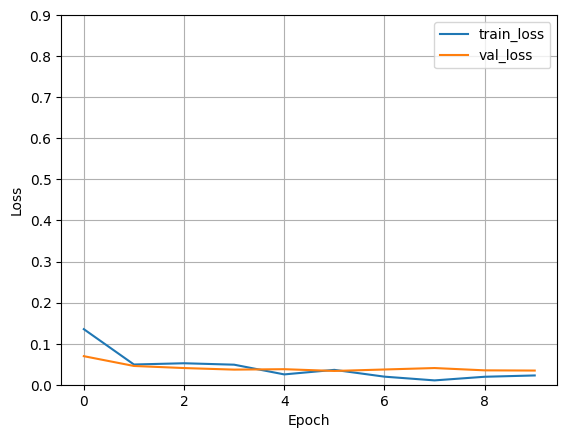

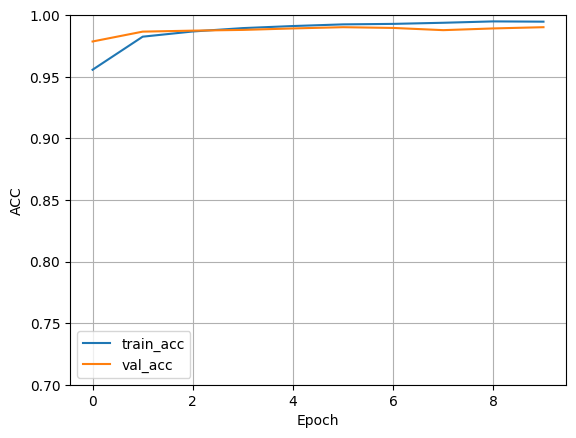

In [ ]:
plot_loss_and_acc(trainer.logger.log_dir)

In [ ]:
trainer.test(model=lightning_model, datamodule=dm)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9890000224113464     │
└───────────────────────────┴───────────────────────────┘

[{'test_acc': 0.9890000224113464}]

---
## Step 7 — Reflection Questions

Answer the following questions in the markdown cell below (double-click to edit).

1. **Why did we have to remove `MaxPool2d` from Block 3 before adding Block 4?** What would happen to the spatial dimensions if we had kept it?

2. **Why did the first number in `Linear(32, 20)` need to change to `Linear(64, 20)`?** What does that number represent?

3. **Compare your 4-block CNN test accuracy to the tutorial's 3-block CNN (~99%).** Is the 4-block model better, worse, or about the same? Suggest one reason why.

**Your answers here:**

1. We had to remove MaxPool because the MaxPool tries to collapse 1 dimension which is impossible, so we need to make space.

2. Since the flattened vector is now 64, we have to update the linear to 64 so that it knows how many inputs to expect.

3. The 4-block model is about the same because the 3-block already achieves a 99% accuracy meaning that the 4th block will not extract very many more features that will further increase accuracy.